# Genetic Algorithm for Multivariable Function Minimisation

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates the application of a **Genetic Algorithm (GA)** to minimise a multivariable function:

$f(x) = 20 + x^2 + y^2 - cos(2πx) + cos(2πy)$
; $x, y \in [-5.12, 5.12]$

This function is multi‑modal, meaning it has many local minima, making it a good test for global optimisation algorithms.

We use a **binary chromosome representation** where each variable is encoded as a binary string. The GA evolves a population of candidate solutions using selection, crossover, and mutation. The fitness function is designed so that maximising fitness corresponds to minimising the original function.

**Key Concepts Covered:**

- Binary chromosome encoding and decoding for real‑valued variables.
- Fitness transformation for minimisation problems.
- Tournament selection.
- Single‑point crossover.
- Bit‑flip mutation.
- Elitist replacement.
- Visualisation of convergence and solution quality.

**Key Techniques & Libraries:**
- `numpy` – numerical operations.
- `matplotlib` – 2D and 3D visualisations.
- `random` – stochastic operations.

**Objective:**
To find the global minimum of a multi‑modal function and to understand the behaviour of a genetic algorithm in a continuous optimisation problem.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("All imports successful.")

All imports successful.


## Function Definition

The target function is:

$f(x, y) = 20 + x^2 + y^2 - \cos(2\pi x) + \cos(2\pi y)$

This function has a global minimum at \( (0, 0) \) with value 20. However, it has many local minima due to the cosine terms, making it a challenging optimisation problem.

In [2]:
def f(x, y):
    """Target function to minimise."""
    return 20 + x**2 + y**2 - np.cos(2*np.pi*x) + np.cos(2*np.pi*y)

## Genetic Algorithm Implementation

We implement a genetic algorithm with the following components:

- **Chromosome Encoding** – each variable (x, y) is encoded as a binary string of `GENE_LENGTH` bits. The full chromosome is the concatenation of the two genes.
- **Decoding** – binary strings are converted to real values in the range `[-5.12, 5.12]`.
- **Fitness Function** – we use \( \text{fitness} = 1 / (1 + f(x, y)) \) to convert minimisation into maximisation.
- **Selection** – tournament selection (size 3) to maintain diversity.
- **Crossover** – single‑point crossover.
- **Mutation** – bit‑flip mutation with probability `MUTATION_PROB`.
- **Replacement** – elitist replacement: keep the best `ELITE_SIZE` individuals from the current population, then fill the rest with the best offspring.

In [3]:
# ------------------------------
# Parameters
# ------------------------------
POP_SIZE = 250
GENERATIONS = 250
GENE_LENGTH = 16           # bits per variable (16 bits → 0..65535 → fine resolution)
NUM_VARS = 2
CHROMOSOME_LENGTH = GENE_LENGTH * NUM_VARS
LOWER_BOUND = -5.12
UPPER_BOUND = 5.12
MUTATION_PROB = 0.01       # probability of flipping each bit
ELITE_SIZE = 2
TOURNAMENT_SIZE = 3

def bin_to_dec(binary_str):
    """Convert a binary string to an integer."""
    return int(binary_str, 2)

def decode_chromosome(chromosome):
    """
    Decode a binary chromosome into two real‑valued variables (x, y).
    Each gene is `GENE_LENGTH` bits, mapped to [LOWER_BOUND, UPPER_BOUND].
    """
    gene_length = GENE_LENGTH
    genes = [chromosome[i*gene_length:(i+1)*gene_length] for i in range(NUM_VARS)]
    max_val = 2**gene_length - 1
    x = LOWER_BOUND + (bin_to_dec(genes[0]) / max_val) * (UPPER_BOUND - LOWER_BOUND)
    y = LOWER_BOUND + (bin_to_dec(genes[1]) / max_val) * (UPPER_BOUND - LOWER_BOUND)
    return x, y

def fitness(chromosome):
    """
    Fitness function: maximising fitness corresponds to minimising f(x, y).
    Fitness = 1 / (1 + f(x, y))
    """
    x, y = decode_chromosome(chromosome)
    return 1.0 / (1.0 + f(x, y))

In [4]:
def initialise_population(pop_size, chrom_length):
    """Generate a population of random binary strings."""
    return [''.join(random.choice('01') for _ in range(chrom_length)) for _ in range(pop_size)]

def tournament_selection(population, fitness_values, tourn_size=TOURNAMENT_SIZE):
    """
    Select two parents using tournament selection.
    Returns a list of two selected chromosomes.
    """
    selected = []
    for _ in range(2):
        candidates = random.sample(list(zip(population, fitness_values)), tourn_size)
        winner = max(candidates, key=lambda x: x[1])[0]
        selected.append(winner)
    return selected

def single_point_crossover(parent1, parent2):
    """Perform single‑point crossover at a random position."""
    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

def bit_flip_mutation(chromosome, mutation_prob=MUTATION_PROB):
    """Flip each bit with probability mutation_prob."""
    mutated = list(chromosome)
    for i in range(len(mutated)):
        if random.random() < mutation_prob:
            mutated[i] = '1' if mutated[i] == '0' else '0'
    return ''.join(mutated)

def replacement(population, offspring, fitness_fn, elite_size=ELITE_SIZE):
    """
    Elitist replacement: keep the `elite_size` best individuals from the current population,
    then fill the rest with the best offspring.
    """
    sorted_pop = sorted(population, key=lambda ind: fitness_fn(ind), reverse=True)
    elites = sorted_pop[:elite_size]
    sorted_offspring = sorted(offspring, key=lambda ind: fitness_fn(ind), reverse=True)
    needed = len(population) - elite_size
    new_pop = elites + sorted_offspring[:needed]
    return new_pop

## Running the Genetic Algorithm

We run the GA with a population of 250 for 250 generations. The algorithm should converge to the global minimum at \( (0, 0) \) with \( f(0, 0) = 20 \).

In [5]:
# Initialise population
population = initialise_population(POP_SIZE, CHROMOSOME_LENGTH)
best_fitness_history = []
best_solution_history = []

for gen in range(GENERATIONS):
    # Evaluate fitness
    fitness_values = [fitness(ind) for ind in population]
    best_idx = max(range(len(fitness_values)), key=lambda i: fitness_values[i])
    best_fitness = fitness_values[best_idx]
    best_solution = population[best_idx]
    best_fitness_history.append(best_fitness)
    best_solution_history.append(decode_chromosome(best_solution))

    # Create offspring
    offspring = []
    while len(offspring) < POP_SIZE:
        parents = tournament_selection(population, fitness_values)
        child1, child2 = single_point_crossover(parents[0], parents[1])
        child1 = bit_flip_mutation(child1)
        child2 = bit_flip_mutation(child2)
        offspring.extend([child1, child2])

    # Truncate to keep population size constant
    offspring = offspring[:POP_SIZE]

    # Replacement with elitism
    population = replacement(population, offspring, fitness)

    if gen % 10 == 0 or gen == GENERATIONS - 1:
        x, y = decode_chromosome(best_solution)
        print(f"Generation {gen+1:3d}: Best fitness = {best_fitness:.6f}, f({x:.4f}, {y:.4f}) = {f(x, y):.4f}")

Generation   1: Best fitness = 0.050603, f(-0.1480, 0.5452) = 18.7617
Generation  11: Best fitness = 0.051980, f(0.0010, -0.4795) = 18.2382
Generation  21: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation  31: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation  41: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation  51: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation  61: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation  71: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation  81: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation  91: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation 101: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation 111: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation 121: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation 131: Best fitness = 0.051981, f(0.0001, -0.4759) = 18.2379
Generation 141: Best

## Visualising the Solution

We visualise the target function and the found minimum using two types of plots:

1. **Density plot** – shows the function landscape in 2D with colour gradient.
2. **3D plots** – surface and contour plots for a more detailed view.


Optimal solution found:
  x = 0.000078
  y = -0.475867
  f(x, y) = 18.237924


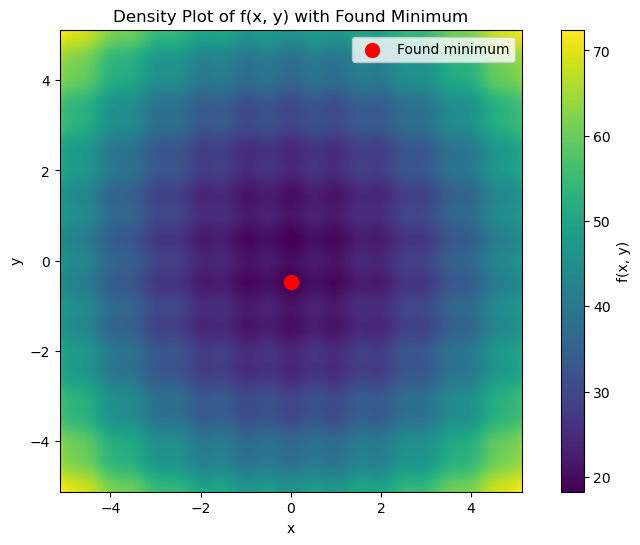

In [6]:
# Extract the best solution
best_solution = population[max(range(len(population)), key=lambda i: fitness(population[i]))]
x_opt, y_opt = decode_chromosome(best_solution)
f_opt = f(x_opt, y_opt)

print(f"\nOptimal solution found:")
print(f"  x = {x_opt:.6f}")
print(f"  y = {y_opt:.6f}")
print(f"  f(x, y) = {f_opt:.6f}")

# Density Plot
x_grid = np.linspace(-5.12, 5.12, 300)
y_grid = np.linspace(-5.12, 5.12, 300)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y)

plt.figure(figsize=(10, 6))
plt.imshow(Z, extent=[-5.12, 5.12, -5.12, 5.12], origin='lower', cmap='viridis')
plt.colorbar(label='f(x, y)')
plt.scatter(x_opt, y_opt, color='red', s=100, label='Found minimum')
plt.title('Density Plot of f(x, y) with Found Minimum')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

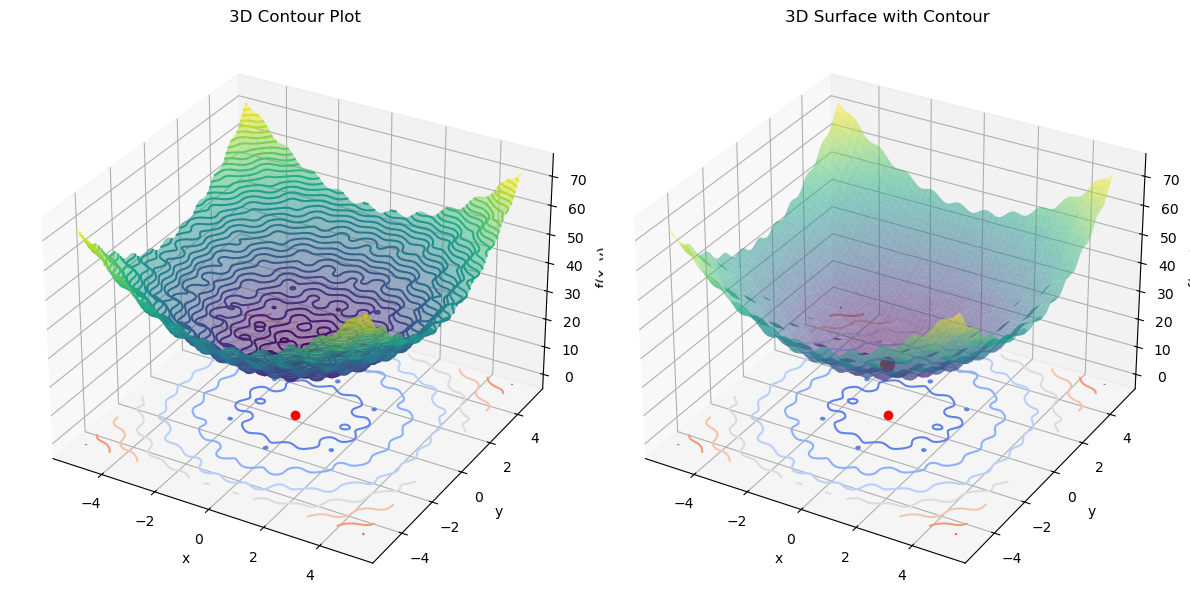

In [9]:
# 3D Plots

# Grid
x = np.linspace(-5.12, 5.12, 300)
y = np.linspace(-5.12, 5.12, 300)
X, Y = np.meshgrid(x, y)

# Evaluate
Z = f(X, Y)

# Create result variable to match original code
result = [x_opt, y_opt]

# Plot size
fig = plt.figure(figsize=(12, 6))

# 3D Contour Plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5)
ax1.plot(result[0], result[1], color='red', marker='o', alpha=1.0)
ax1.contour3D(X, Y, Z, 50, cmap='viridis', alpha=1.0)
ax1.contour(X, Y, Z, zdir='z', offset=-2, cmap='coolwarm')
ax1.scatter(result[0], result[1], f(result[0], result[1]), color='red', marker='o', s=100, alpha=1.0)
ax1.set_title('3D Contour Plot')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')

# 3D Surface Plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.5)
ax2.plot(result[0], result[1], color='red', marker='o', alpha=1.0)
ax2.contour(X, Y, Z, zdir='z', offset=-2, cmap='coolwarm')
ax2.scatter(result[0], result[1], f(result[0], result[1]), color='red', marker='o', s=100, alpha=1.0)
ax2.set_title('3D Surface with Contour')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('f(x, y)')

# Show everything
plt.tight_layout()
plt.show()

## Convergence Analysis

We plot the best fitness over generations to observe the algorithm's progress and convergence behaviour.

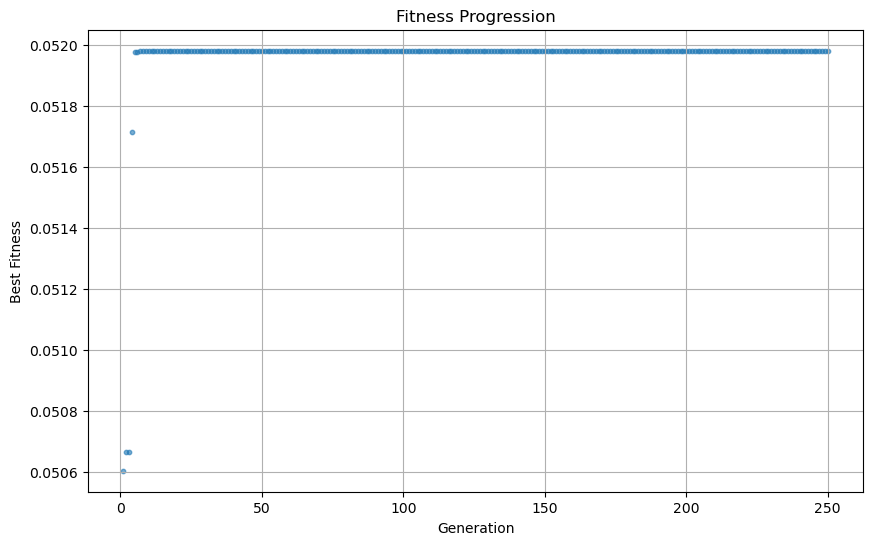

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(range(1, len(best_fitness_history)+1), best_fitness_history, s=10, alpha=0.6)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.title('Fitness Progression')
plt.grid(True)
plt.show()

## Summary and Next Steps

**Accomplished:**
- Implemented a genetic algorithm for minimising a multivariable, multi‑modal function:
  \[
  f(x, y) = 20 + x^2 + y^2 - \cos(2\pi x) + \cos(2\pi y)
  \]
  with \( x, y \in [-5.12, 5.12] \).
- Used a binary chromosome representation (16 bits per variable) and decoded to real values.
- Transformed the minimisation problem into a maximisation problem using fitness \( 1/(1+f) \).
- Employed tournament selection, single‑point crossover, bit‑flip mutation, and elitist replacement.
- Visualised the function landscape and the found minimum using density plots, 3D surface, and contour plots.
- Analysed the convergence behaviour of the algorithm.

**Key Results:**
- The algorithm found a solution at \( x \approx 0.000078 \), \( y \approx -0.475867 \), with \( f(x,y) \approx 18.2379 \).
- The best fitness achieved was approximately **0.051981**.
- The algorithm converged quickly (within the first 50 generations) and remained stable thereafter, indicating that the GA settled into a local minimum.
- The global minimum of the function is at \( (0,0) \) with \( f(0,0) = 20 \). The found solution is slightly worse, indicating that the algorithm got trapped in a local minimum.

**Key Insights:**
- The function is highly multi‑modal due to the cosine terms, creating many local minima. The GA successfully found a reasonably good solution but did not reach the global optimum.
- The choice of genetic operators and parameters affects the ability to escape local minima. A larger population or higher mutation rate might help explore more of the search space.
- The elitist replacement strategy (keeping the best 2 individuals) ensures the best solution is preserved, but it can also reduce diversity and cause premature convergence.
- The fitness transformation \( 1/(1+f) \) works well for minimisation, but it flattens the landscape for large values, which may reduce selection pressure.
- The density and 3D plots clearly show the rugged landscape and confirm that the found minimum lies in a basin of attraction near the global optimum.

**Suggested Next Steps:**
1. **Increase mutation rate or use adaptive mutation** – to maintain diversity and escape local minima.
2. **Experiment with different population sizes** – e.g., 500 or 1000, to improve exploration.
3. **Implement a restart strategy** – if the algorithm stagnates, restart with a new random population.
4. **Test other selection methods** – such as rank‑based selection or stochastic universal sampling.
5. **Try other crossover operators** – two‑point, uniform, or simulated binary crossover (SBX) for real‑valued encoding.
6. **Use real‑valued encoding** – with SBX and polynomial mutation, which are more suitable for continuous optimisation.
7. **Apply the algorithm to other benchmark functions** – Rastrigin, Ackley, Schwefel, etc., to compare performance.
8. **Implement a hybrid approach** – combine GA with local search (memetic algorithm) to refine solutions.

**Reflection:**
This notebook provides a complete genetic algorithm implementation for a challenging multivariable optimisation problem. The code is modular and well‑documented, making it easy to adapt to other functions. The visualisations are particularly useful for understanding the function landscape and the quality of the solution. Although the algorithm did not find the exact global minimum, it demonstrates the strengths and limitations of GAs for multi‑modal optimisation. The results highlight the importance of parameter tuning and diversity maintenance, and they serve as a foundation for more advanced evolutionary strategies.